# MoonBoard Edge-Ease GNN Final Delta Report

이 노트북은 **실험 실행 → baseline 대비 개선량 계산 → 최종 판정표 출력**까지 한 번에 합니다.

맨 마지막 섹션의 표가 핵심입니다.

- `delta_*`가 `+`이면 baseline보다 오른 것입니다.
- `micro_f1`은 single-label multi-class에서 `exact_acc`와 같습니다.
- edge-ease가 의미 있는지는 `delta_macro_f1`, `delta_weighted_f1`, `delta_rare_recall`, `corr_bottleneck_ease`, `corr_low_ease_mass`를 같이 봅니다.

필요 파일:

- `moonGen_scrape_2016_final`
- `HoldFeature2016LeftHand.csv`
- `HoldFeature2016RightHand.csv`


In [ ]:
# Colab 등에서 패키지가 없으면 이 셀의 주석을 해제해서 실행하세요.
# !pip install -q torch-geometric scikit-learn pandas matplotlib tqdm

In [1]:
from pathlib import Path

ROOT = Path.cwd()
DATA_FILES = [
    "moonGen_scrape_2016_final",
    "HoldFeature2016LeftHand.csv",
    "HoldFeature2016RightHand.csv",
]

print("working directory:", ROOT)
for name in DATA_FILES:
    path = ROOT / name
    print(f"{name}: exists={path.exists()} size={path.stat().st_size if path.exists() else 'missing'}")

working directory: C:\Users\maxma\PycharmProjects\CS471-MoonboardGNN
moonGen_scrape_2016_final: exists=True size=18644006
HoldFeature2016LeftHand.csv: exists=True size=1379
HoldFeature2016RightHand.csv: exists=True size=1097


## 1. 설정

처음에는 `MAX_SAMPLES=5000`, `EPOCHS=10` 정도로 빠르게 sanity check를 권장합니다.

최종 비교는 `MAX_SAMPLES=None`, `EPOCHS=20` 이상으로 돌리는 것이 좋습니다.

In [2]:
CONFIG = {
    "raw_path": Path("moonGen_scrape_2016_final"),
    "left_diff_path": Path("HoldFeature2016LeftHand.csv"),
    "right_diff_path": Path("HoldFeature2016RightHand.csv"),
    "output_root": Path("outputs_edge_ease_experiments"),
    "dataset": "all",          # "all", "benchmark", "nonbenchmark"
    "max_samples": 5000,       # 빠른 실험: 5000 / 전체 실험: None
    "epochs": 10,
    "batch_size": 128,
    "hidden": 64,
    "lr": 0.005,
    "seed": 471,
    "reach_threshold": 0.4,
    "order_mode": "source",
    "feature_set": "difficulty_direction",
    "edge_mode": "spatial",
}
CONFIG["output_root"].mkdir(parents=True, exist_ok=True)
CONFIG

{'raw_path': WindowsPath('moonGen_scrape_2016_final'),
 'left_diff_path': WindowsPath('HoldFeature2016LeftHand.csv'),
 'right_diff_path': WindowsPath('HoldFeature2016RightHand.csv'),
 'output_root': WindowsPath('outputs_edge_ease_experiments'),
 'dataset': 'all',
 'max_samples': 5000,
 'epochs': 10,
 'batch_size': 128,
 'hidden': 64,
 'lr': 0.005,
 'seed': 471,
 'reach_threshold': 0.4,
 'order_mode': 'source',
 'feature_set': 'difficulty_direction',
 'edge_mode': 'spatial'}

## 2. Imports and utilities

In [3]:
import csv
import json
import pickle
import random
import time
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch import nn

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, GCNConv, SAGEConv, global_max_pool

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def write_json(path: Path, value) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, ensure_ascii=False), encoding="utf-8")

C:\Users\maxma\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Dataset loading

등급 label은 기존 MoonBoardRNN/레포 설정과 동일하게 10개 class로 묶습니다.

In [4]:
GRADE_MAP = {
    "6B": 0,
    "6B+": 0,
    "6C": 1,
    "6C+": 1,
    "7A": 2,
    "7A+": 3,
    "7B": 4,
    "7B+": 4,
    "7C": 5,
    "7C+": 6,
    "8A": 7,
    "8A+": 8,
    "8B": 9,
}

ID_TO_GRADE_GROUP = {
    0: "6B/6B+",
    1: "6C/6C+",
    2: "7A",
    3: "7A+",
    4: "7B/7B+",
    5: "7C",
    6: "7C+",
    7: "8A",
    8: "8A+",
    9: "8B",
}

HOLD_DIRECTION_RAW = """
1 - H7 - SE
2 - J14 - NW
3 - K7 - N
4 - D8 - N
5 - A16 - NW
6 - F6 - E
7 - K6 - N
8 - C9 - W
9 - A10 - SW
10 - I8 - N
11 - K12 - N
12 - A11 - SE
13 - B7 - S
14 - D16 - N
15 - K10 - S
16 - G16 - N
17 - F8 - N
18 - F15 - N
19 - G7 - SW
20 - H15 - NE
21 - C12 - N
22 - D6 - N
23 - D3 - S
24 - D13 - N
25 - J11 - N
26 - A13 - N
27 - G11 - E
28 - H18 - N
29 - B4 - SW
30 - K8 - N
31 - C15 - NW
32 - H9 - E
33 - D10 - NW
34 - H14 - W
35 - I5 - N
36 - I12 - SW
37 - K13 - N
38 - C7 - N
39 - C18 - N
40 - F9 - N
50 - C14 - N
51 - D17 - N
52 - D9 - NE
53 - F7 - NW
54 - F12 - E
55 - G12 - NE
56 - B11 - NW
57 - J10 - NE
58 - J2 - SE
59 - E13 - N
60 - I6 - NE
61 - J9 - SE
62 - F14 - NW
63 - I13 - E
64 - E10 - NW
65 - F10 - NE
66 - E15 - NW
67 - B8 - N
68 - A12 - E
69 - I16 - NE
70 - I11 - N
71 - B16 - NW
72 - E11 - N
73 - H11 - W
74 - E7 - S
75 - D12 - N
76 - J8 - N
77 - B13 - NW
78 - B9 - NE
79 - C10 - NE
80 - B3 - SW
81 - G2 - N
82 - G18 - W
83 - I4 - NE
84 - K11 - NW
85 - A5 - N
86 - K5 - N
87 - K18 - W
88 - G8 - N
89 - F5 - N
90 - G13 - N
91 - E18 - N
92 - J6 - S
93 - D14 - N
94 - C11 - W
95 - C6 - S
96 - F16 - S
97 - D5 - NW
98 - A15 - N
99 - B18 - SE
100 - H16 - N
101 - B15 - N
102 - J12 - NE
103 - J13 - N
104 - K16 - N
105 - F13 - NW
106 - E16 - NW
107 - I7 - NE
108 - I15 - NW
109 - I9 - SE
110 - E12 - NE
111 - H5 - NW
112 - G15 - NW
113 - J7 - N
114 - H12 - NW
115 - G17 - N
116 - E9 - NE
117 - J16 - E
118 - F11 - NE
119 - D11 - SW
120 - I10 - N
121 - K9 - N
122 - E8 - N
123 - A14 - NW
124 - I14 - NW
125 - C5 - N
126 - D15 - NW
127 - E14 - E
128 - G9 - NE
129 - E6 - NW
130 - J5 - NW
131 - H8 - NE
132 - I18 - NE
133 - A9 - NW
134 - G6 - SW
135 - C8 - NW
136 - D18 - N
137 - G14 - E
138 - C13 - NW
139 - A18 - N
140 - H10 - NE
141 - G4 - N
142 - B12 - SE
143 - C16 - N
144 - K14 - NE
145 - G10 - NE
146 - D7 - S
147 - B6 - NW
148 - B10 - SE
149 - H13 - SW
"""

DIRECTION_VECTORS = {
    "N": (0.0, 1.0),
    "NE": (0.707, 0.707),
    "E": (1.0, 0.0),
    "SE": (0.707, -0.707),
    "S": (0.0, -1.0),
    "SW": (-0.707, -0.707),
    "W": (-1.0, 0.0),
    "NW": (-0.707, 0.707),
}


def build_hold_direction_map() -> dict[tuple[int, int], tuple[float, float]]:
    result = {}
    for line in HOLD_DIRECTION_RAW.strip().splitlines():
        parts = [p.strip() for p in line.split(" - ")]
        if len(parts) != 3:
            continue
        hold = parts[1]
        direction = parts[2]
        x = ord(hold[0].upper()) - ord("A")
        y = int(hold[1:]) - 1
        result[(x, y)] = DIRECTION_VECTORS[direction]
    return result


HOLD_DIRECTIONS = build_hold_direction_map()


@dataclass(frozen=True)
class Problem:
    key: str
    grade: str
    label: int
    start: tuple[tuple[int, int], ...]
    mid: tuple[tuple[int, int], ...]
    end: tuple[tuple[int, int], ...]
    is_benchmark: bool


def load_hold_difficulties(path: Path) -> dict[tuple[int, int], float]:
    values: dict[tuple[int, int], float] = {}
    with path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if not row.get("X_coord") or not row.get("Y_coord"):
                continue
            x = int(float(row["X_coord"]))
            y = int(float(row["Y_coord"]))
            diff = float(row["Difficulties"])
            values[(x, y)] = diff
    return values


def load_problems(raw_path: Path, dataset: str, max_samples: int | None, seed: int) -> list[Problem]:
    raw = pickle.load(raw_path.open("rb"))
    problems: list[Problem] = []
    for key, item in raw.items():
        grade = item.get("grade")
        if grade not in GRADE_MAP:
            continue
        if dataset == "benchmark" and not item.get("is_benchmark"):
            continue
        if dataset == "nonbenchmark" and item.get("is_benchmark"):
            continue

        start = tuple(tuple(map(int, hold)) for hold in item.get("start", []))
        mid = tuple(tuple(map(int, hold)) for hold in item.get("mid", []))
        end = tuple(tuple(map(int, hold)) for hold in item.get("end", []))
        if not start or not end:
            continue

        problems.append(
            Problem(
                key=str(key),
                grade=grade,
                label=GRADE_MAP[grade],
                start=start,
                mid=mid,
                end=end,
                is_benchmark=bool(item.get("is_benchmark")),
            )
        )

    rng = random.Random(seed)
    rng.shuffle(problems)
    if max_samples is not None:
        problems = problems[:max_samples]
    return problems

## 4. Graph construction with edge attributes

기존 레포는 `edge_index`만 만들었습니다. 여기서는 `edge_attr`도 만듭니다.

중요한 점:

- edge 수 자체를 “쉬움”으로 쓰지 않습니다.
- 각 directed edge `(i → j)`마다 이동 feature를 만들고, 모델이 그 edge의 `ease_ij`를 학습합니다.
- `ease_ij`는 나중에 message gate로 사용됩니다.

In [5]:
TYPE_TO_ID = {"start": 0, "mid": 1, "end": 2}


def ordered_holds(problem: Problem, order_mode: str) -> list[tuple[tuple[int, int], str]]:
    start = sorted(problem.start, key=lambda xy: (xy[1], xy[0]))
    mid = list(problem.mid)
    end = sorted(problem.end, key=lambda xy: (xy[1], xy[0]))

    if order_mode == "source":
        mid_ordered = mid
    elif order_mode == "height":
        mid_ordered = sorted(mid, key=lambda xy: (xy[1], xy[0]))
    elif order_mode == "none":
        mid_ordered = sorted(mid, key=lambda xy: (xy[0], xy[1]))
    else:
        raise ValueError(f"unknown order_mode: {order_mode}")

    return (
        [(xy, "start") for xy in start]
        + [(xy, "mid") for xy in mid_ordered]
        + [(xy, "end") for xy in end]
    )


def node_feature(
    xy: tuple[int, int],
    hold_type: str,
    position: int,
    n_holds: int,
    feature_set: str,
    left_diff: dict[tuple[int, int], float],
    right_diff: dict[tuple[int, int], float],
) -> list[float]:
    x, y = xy
    feat = [x / 10.0, y / 17.0]

    if feature_set in {
        "type", "type_order", "direction", "direction_order",
        "difficulty", "difficulty_order", "difficulty_direction",
        "difficulty_direction_order",
    }:
        feat.extend([
            1.0 if hold_type == "start" else 0.0,
            1.0 if hold_type == "mid" else 0.0,
            1.0 if hold_type == "end" else 0.0,
        ])

    if feature_set in {"direction", "direction_order", "difficulty_direction", "difficulty_direction_order"}:
        feat.extend(HOLD_DIRECTIONS.get(xy, (0.0, 1.0)))

    if feature_set in {"difficulty", "difficulty_order", "difficulty_direction", "difficulty_direction_order"}:
        feat.extend([
            left_diff.get(xy, 0.0) / 10.0,
            right_diff.get(xy, 0.0) / 10.0,
        ])

    if feature_set in {"type_order", "direction_order", "difficulty_order", "difficulty_direction_order"}:
        denom = max(1, n_holds - 1)
        feat.append(position / denom)

    return feat


def type_one_hot(hold_type: str) -> list[float]:
    return [
        1.0 if hold_type == "start" else 0.0,
        1.0 if hold_type == "mid" else 0.0,
        1.0 if hold_type == "end" else 0.0,
    ]


def edge_feature(
    src_xy: tuple[int, int],
    dst_xy: tuple[int, int],
    src_type: str,
    dst_type: str,
    left_diff: dict[tuple[int, int], float],
    right_diff: dict[tuple[int, int], float],
) -> list[float]:
    xi, yi = src_xy
    xj, yj = dst_xy

    dx = xj - xi
    dy = yj - yi
    dx_norm = dx / 10.0
    dy_norm = dy / 17.0
    abs_dx_norm = abs(dx) / 10.0
    abs_dy_norm = abs(dy) / 17.0
    dist_norm = ((dx ** 2 + dy ** 2) ** 0.5) / ((10 ** 2 + 17 ** 2) ** 0.5)

    upward = 1.0 if dy > 0 else 0.0
    downward = 1.0 if dy < 0 else 0.0
    lateral = 1.0 if dy == 0 else 0.0

    move_norm = (dx ** 2 + dy ** 2) ** 0.5
    if move_norm > 0:
        move_vec = (dx / move_norm, dy / move_norm)
    else:
        move_vec = (0.0, 0.0)

    src_dir = HOLD_DIRECTIONS.get(src_xy, (0.0, 1.0))
    dst_dir = HOLD_DIRECTIONS.get(dst_xy, (0.0, 1.0))

    src_alignment = src_dir[0] * move_vec[0] + src_dir[1] * move_vec[1]
    dst_receive_alignment = dst_dir[0] * (-move_vec[0]) + dst_dir[1] * (-move_vec[1])

    return [
        dx_norm,
        dy_norm,
        abs_dx_norm,
        abs_dy_norm,
        dist_norm,
        upward,
        downward,
        lateral,
        yi / 17.0,
        yj / 17.0,
        src_alignment,
        dst_receive_alignment,
        left_diff.get(src_xy, 0.0) / 10.0,
        right_diff.get(src_xy, 0.0) / 10.0,
        left_diff.get(dst_xy, 0.0) / 10.0,
        right_diff.get(dst_xy, 0.0) / 10.0,
        *type_one_hot(src_type),
        *type_one_hot(dst_type),
    ]


EDGE_ATTR_NAMES = [
    "dx_norm", "dy_norm", "abs_dx_norm", "abs_dy_norm", "dist_norm",
    "upward", "downward", "lateral",
    "src_y_norm", "dst_y_norm",
    "src_direction_alignment", "dst_receive_alignment",
    "src_left_diff", "src_right_diff", "dst_left_diff", "dst_right_diff",
    "src_is_start", "src_is_mid", "src_is_end",
    "dst_is_start", "dst_is_mid", "dst_is_end",
]


def create_edges_and_attrs(
    holds: list[tuple[tuple[int, int], str]],
    edge_mode: str,
    reach_threshold: float,
    left_diff: dict[tuple[int, int], float],
    right_diff: dict[tuple[int, int], float],
) -> tuple[torch.Tensor, torch.Tensor]:
    edge_set: set[tuple[int, int]] = set()
    coords = [xy for xy, _ in holds]

    if edge_mode in {"spatial", "hybrid"}:
        for i, (xi, yi) in enumerate(coords):
            for j, (xj, yj) in enumerate(coords):
                if i == j:
                    continue
                dist = ((xi - xj) ** 2 + (yi - yj) ** 2) ** 0.5 / ((10**2 + 17**2) ** 0.5)
                if dist <= reach_threshold:
                    edge_set.add((i, j))

    if edge_mode in {"sequence", "hybrid"}:
        for i in range(len(holds) - 1):
            edge_set.add((i, i + 1))
            edge_set.add((i + 1, i))

    if not edge_set:
        for i in range(len(holds)):
            edge_set.add((i, i))

    edge_list = sorted(edge_set)
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    attrs = []
    for i, j in edge_list:
        src_xy, src_type = holds[i]
        dst_xy, dst_type = holds[j]
        attrs.append(edge_feature(src_xy, dst_xy, src_type, dst_type, left_diff, right_diff))

    edge_attr = torch.tensor(attrs, dtype=torch.float32)
    return edge_index, edge_attr


def problem_to_graph(
    problem: Problem,
    feature_set: str,
    edge_mode: str,
    order_mode: str,
    reach_threshold: float,
    left_diff: dict[tuple[int, int], float],
    right_diff: dict[tuple[int, int], float],
) -> Data:
    holds = ordered_holds(problem, order_mode)
    features = [
        node_feature(
            xy=xy,
            hold_type=hold_type,
            position=i,
            n_holds=len(holds),
            feature_set=feature_set,
            left_diff=left_diff,
            right_diff=right_diff,
        )
        for i, (xy, hold_type) in enumerate(holds)
    ]
    x = torch.tensor(features, dtype=torch.float32)
    edge_index, edge_attr = create_edges_and_attrs(
        holds=holds,
        edge_mode=edge_mode,
        reach_threshold=reach_threshold,
        left_diff=left_diff,
        right_diff=right_diff,
    )
    y = torch.tensor([problem.label], dtype=torch.long)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    data.problem_key = problem.key
    data.grade = problem.grade
    return data

## 5. Models

`EaseGatedGNNClassifier`가 이 노트북의 핵심입니다.

- `edge_ease_mlp(edge_attr)`가 각 edge의 쉬움 정도를 예측합니다.
- `message = ease * projected_source_node`로 message passing을 합니다.
- graph-level classifier에는 node representation과 ease summary가 같이 들어갑니다.
- 선택적으로 `ease_grade_bias_strength`를 켜면, learned ease가 낮을수록 높은 grade logit을 밀어주는 방향을 약하게 강제합니다.

In [6]:
class GATClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_classes: int):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4, concat=False)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=4, concat=False)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ELU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ELU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels // 2, num_classes),
        )

    def forward(self, x, edge_index, batch, edge_attr=None, return_aux=False):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        graph_h = global_max_pool(x, batch)
        logits = self.mlp(graph_h)
        if return_aux:
            return logits, {}
        return logits


class GCNClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_classes: int):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels, num_classes),
        )

    def forward(self, x, edge_index, batch, edge_attr=None, return_aux=False):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        graph_h = global_max_pool(x, batch)
        logits = self.mlp(graph_h)
        if return_aux:
            return logits, {}
        return logits


class SAGEClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_classes: int):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels, num_classes),
        )

    def forward(self, x, edge_index, batch, edge_attr=None, return_aux=False):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        graph_h = global_max_pool(x, batch)
        logits = self.mlp(graph_h)
        if return_aux:
            return logits, {}
        return logits


def group_mean(values: torch.Tensor, group_index: torch.Tensor, num_groups: int) -> torch.Tensor:
    out = values.new_zeros(num_groups)
    count = values.new_zeros(num_groups)
    out.index_add_(0, group_index, values)
    count.index_add_(0, group_index, torch.ones_like(values))
    return out / count.clamp_min(1.0)


def group_logmeanexp(values: torch.Tensor, group_index: torch.Tensor, num_groups: int) -> torch.Tensor:
    result = []
    for g in range(num_groups):
        v = values[group_index == g]
        if v.numel() == 0:
            result.append(values.new_tensor(0.0))
        else:
            result.append(torch.logsumexp(v, dim=0) - torch.log(values.new_tensor(float(v.numel()))))
    return torch.stack(result, dim=0)


def group_softmin(values: torch.Tensor, group_index: torch.Tensor, num_groups: int, tau: float = 0.15) -> torch.Tensor:
    return -tau * group_logmeanexp(-values / tau, group_index, num_groups)


class EaseMessageLayer(nn.Module):
    def __init__(self, hidden_channels: int):
        super().__init__()
        self.msg_proj = nn.Linear(hidden_channels, hidden_channels)
        self.self_proj = nn.Linear(hidden_channels, hidden_channels)
        self.norm = nn.LayerNorm(hidden_channels)

    def forward(self, h: torch.Tensor, edge_index: torch.Tensor, ease: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index
        messages = ease.unsqueeze(-1) * self.msg_proj(h[src])

        agg = torch.zeros_like(h)
        norm = h.new_zeros(h.size(0), 1)

        agg.index_add_(0, dst, messages)
        norm.index_add_(0, dst, ease.unsqueeze(-1))

        agg = agg / norm.clamp_min(1e-6)
        out = self.self_proj(h) + agg
        out = self.norm(out)
        return F.elu(out)


class EaseGatedGNNClassifier(nn.Module):
    def __init__(
        self,
        in_channels: int,
        edge_channels: int,
        hidden_channels: int,
        num_classes: int,
        num_layers: int = 2,
        ease_grade_bias_strength: float = 0.0,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.ease_grade_bias_strength = float(ease_grade_bias_strength)

        self.node_proj = nn.Linear(in_channels, hidden_channels)

        self.edge_ease_mlp = nn.Sequential(
            nn.Linear(edge_channels, hidden_channels),
            nn.ELU(),
            nn.Dropout(p=0.1),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ELU(),
            nn.Linear(hidden_channels // 2, 1),
            nn.Sigmoid(),
        )

        self.layers = nn.ModuleList([EaseMessageLayer(hidden_channels) for _ in range(num_layers)])

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels + 3, hidden_channels),
            nn.ELU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ELU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_channels // 2, num_classes),
        )

    def forward(self, x, edge_index, batch, edge_attr=None, return_aux=False):
        if edge_attr is None:
            raise ValueError("EaseGatedGNNClassifier requires edge_attr.")

        h = F.elu(self.node_proj(x))
        ease = self.edge_ease_mlp(edge_attr).squeeze(-1).clamp(1e-4, 1.0 - 1e-4)

        for layer in self.layers:
            h = layer(h, edge_index, ease)
            h = F.dropout(h, p=0.2, training=self.training)

        graph_h = global_max_pool(h, batch)
        num_graphs = int(batch.max().item()) + 1

        src, dst = edge_index
        edge_batch = batch[dst]

        mean_ease = group_mean(ease, edge_batch, num_graphs)
        bottleneck_ease = group_softmin(ease, edge_batch, num_graphs, tau=0.15)
        low_ease_mass = group_mean(1.0 - ease, edge_batch, num_graphs)

        graph_edge_stats = torch.stack([mean_ease, bottleneck_ease, low_ease_mass], dim=1)
        graph_repr = torch.cat([graph_h, graph_edge_stats], dim=1)

        logits = self.classifier(graph_repr)

        if self.ease_grade_bias_strength > 0:
            hardness = 0.5 * (1.0 - bottleneck_ease) + 0.5 * low_ease_mass
            grade_axis = torch.linspace(-1.0, 1.0, self.num_classes, device=logits.device)
            logits = logits + self.ease_grade_bias_strength * hardness.unsqueeze(1) * grade_axis.unsqueeze(0)

        aux = {
            "edge_ease": ease,
            "mean_ease": mean_ease,
            "bottleneck_ease": bottleneck_ease,
            "low_ease_mass": low_ease_mass,
        }

        if return_aux:
            return logits, aux
        return logits


def make_model(model_name: str, in_channels: int, edge_channels: int, hidden_channels: int, num_classes: int, **kwargs):
    if model_name == "gat":
        return GATClassifier(in_channels, hidden_channels, num_classes)
    if model_name == "gcn":
        return GCNClassifier(in_channels, hidden_channels, num_classes)
    if model_name == "sage":
        return SAGEClassifier(in_channels, hidden_channels, num_classes)
    if model_name == "ease_gated":
        return EaseGatedGNNClassifier(
            in_channels=in_channels,
            edge_channels=edge_channels,
            hidden_channels=hidden_channels,
            num_classes=num_classes,
            num_layers=kwargs.get("num_layers", 2),
            ease_grade_bias_strength=kwargs.get("ease_grade_bias_strength", 0.0),
        )
    raise ValueError(f"unknown model: {model_name}")

## 6. Training and evaluation

`ease_supervision_weight`는 edge label이 없는 상황에서 `ease`의 의미를 고정하기 위한 약한 보조 loss입니다.

```text
target_graph_ease = 1 - grade_index / (num_classes - 1)
```

즉 낮은 grade 문제는 평균적으로 learned bottleneck ease가 높고, 높은 grade 문제는 낮도록 약하게 유도합니다.

이 값은 **edge count를 쓰지 않습니다.** learned edge ease에서 계산한 graph-level bottleneck ease만 씁니다.

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, weight: torch.Tensor | None = None):
        super().__init__()
        self.gamma = float(gamma)
        self.register_buffer("weight", weight if weight is not None else None)

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1.0 - pt) ** self.gamma) * ce
        return loss.mean()


def evaluate(model: nn.Module, loader: DataLoader, device: torch.device, num_classes: int) -> dict[str, object]:
    model.eval()
    y_true: list[int] = []
    y_pred: list[int] = []
    y_prob_expected: list[float] = []
    ease_rows = []

    grade_axis = torch.arange(num_classes, dtype=torch.float32, device=device)

    with torch.no_grad():
        for batch_data in loader:
            batch_data = batch_data.to(device)
            logits, aux = model(
                batch_data.x,
                batch_data.edge_index,
                batch_data.batch,
                edge_attr=getattr(batch_data, "edge_attr", None),
                return_aux=True,
            )
            probs = F.softmax(logits, dim=1)
            expected_grade = (probs * grade_axis.unsqueeze(0)).sum(dim=1)
            pred = logits.argmax(dim=1)

            y_true.extend(batch_data.y.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())
            y_prob_expected.extend(expected_grade.detach().cpu().tolist())

            if aux:
                for graph_i in range(batch_data.num_graphs):
                    ease_rows.append({
                        "label": int(batch_data.y[graph_i].detach().cpu()),
                        "pred": int(pred[graph_i].detach().cpu()),
                        "expected_grade": float(expected_grade[graph_i].detach().cpu()),
                        "mean_ease": float(aux["mean_ease"][graph_i].detach().cpu()),
                        "bottleneck_ease": float(aux["bottleneck_ease"][graph_i].detach().cpu()),
                        "low_ease_mass": float(aux["low_ease_mass"][graph_i].detach().cpu()),
                    })

    exact = accuracy_score(y_true, y_pred)
    y_true_array = np.array(y_true)
    y_pred_array = np.array(y_pred)
    y_expected_array = np.array(y_prob_expected)

    relaxed = float(np.mean(np.abs(y_true_array - y_pred_array) <= 1))
    within2 = float(np.mean(np.abs(y_true_array - y_pred_array) <= 2))
    mae = float(np.mean(np.abs(y_true_array - y_pred_array)))
    expected_mae = float(np.mean(np.abs(y_true_array - y_expected_array)))
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    labels_list = list(range(num_classes))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_list, zero_division=0
    )
    per_class = {
        str(label): {
            "grade_group": ID_TO_GRADE_GROUP.get(label, str(label)),
            "precision": float(precision[label]),
            "recall": float(recall[label]),
            "f1": float(f1[label]),
            "support": int(support[label]),
        }
        for label in labels_list
    }
    matrix = confusion_matrix(y_true, y_pred, labels=labels_list).astype(int).tolist()

    rare_labels = [5, 6, 7, 8, 9]
    rare_f1 = float(np.mean([f1[i] for i in rare_labels if i < len(f1)]))
    rare_recall = float(np.mean([recall[i] for i in rare_labels if i < len(recall)]))

    result = {
        "exact_acc": float(exact),
        "relaxed_acc": float(relaxed),
        "within2_acc": within2,
        "mae": mae,
        "expected_mae": expected_mae,
        "macro_f1": float(macro_f1),
        "rare_f1_avg_5_9": rare_f1,
        "rare_recall_avg_5_9": rare_recall,
        "per_class": per_class,
        "confusion_matrix": matrix,
    }

    if ease_rows:
        ease_df = pd.DataFrame(ease_rows)
        result["ease_summary"] = {
            "mean_ease_by_label": {int(k): float(v) for k, v in ease_df.groupby("label")["mean_ease"].mean().to_dict().items()},
            "bottleneck_ease_by_label": {int(k): float(v) for k, v in ease_df.groupby("label")["bottleneck_ease"].mean().to_dict().items()},
            "low_ease_mass_by_label": {int(k): float(v) for k, v in ease_df.groupby("label")["low_ease_mass"].mean().to_dict().items()},
            "corr_label_mean_ease": float(ease_df["label"].corr(ease_df["mean_ease"])),
            "corr_label_bottleneck_ease": float(ease_df["label"].corr(ease_df["bottleneck_ease"])),
            "corr_label_low_ease_mass": float(ease_df["label"].corr(ease_df["low_ease_mass"])),
        }

    return result


def compute_class_weights(labels_for_weight: list[int], num_classes: int, mode: str) -> torch.Tensor | None:
    if mode == "none":
        return None

    counts = np.bincount(np.array(labels_for_weight, dtype=np.int64), minlength=num_classes).astype(np.float32)
    present = counts > 0

    if mode == "balanced":
        weights = np.zeros(num_classes, dtype=np.float32)
        weights[present] = len(labels_for_weight) / (float(present.sum()) * counts[present])
        return torch.tensor(weights, dtype=torch.float32)

    if mode == "sqrt_balanced":
        weights = np.zeros(num_classes, dtype=np.float32)
        base = len(labels_for_weight) / (float(present.sum()) * counts[present])
        weights[present] = np.sqrt(base)
        weights[present] = weights[present] / weights[present].mean()
        return torch.tensor(weights, dtype=torch.float32)

    if mode == "effective_num":
        # Cui et al.-style effective number weighting. beta close to 1 raises rare class weight without full inverse-frequency blowup.
        beta = 0.999
        weights = np.zeros(num_classes, dtype=np.float32)
        effective_num = 1.0 - np.power(beta, counts[present])
        weights[present] = (1.0 - beta) / effective_num
        weights[present] = weights[present] / weights[present].mean()
        return torch.tensor(weights, dtype=torch.float32)

    if mode == "moonboardrnn_v1":
        weights = [1, 1, 2, 2, 1, 4, 2, 4, 8, 8]
        return torch.tensor(weights[:num_classes], dtype=torch.float32)

    if mode == "moonboardrnn_v2":
        weights = [1, 1, 2, 4, 1, 4, 8, 8, 8, 8]
        return torch.tensor(weights[:num_classes], dtype=torch.float32)

    raise ValueError(f"unknown class weight mode: {mode}")


def sample_train_indices(
    labels_all: list[int],
    train_idx: np.ndarray,
    mode: str,
    seed: int,
    samples_per_class: int = 1000,
    cap_multiplier: float = 5.0,
    power: float = 0.5,
) -> np.ndarray:
    if mode == "none":
        return np.array(train_idx, dtype=np.int64)

    rng = np.random.default_rng(seed)
    by_class: dict[int, list[int]] = {}
    for idx in train_idx:
        by_class.setdefault(labels_all[int(idx)], []).append(int(idx))

    counts = {label: len(indices) for label, indices in by_class.items()}
    max_count = max(counts.values())

    target_counts = {}
    for label, count in counts.items():
        if mode == "fixed_replacement":
            target = samples_per_class
        elif mode == "capped_replacement":
            # 소수 class를 늘리되, 원본 수의 cap_multiplier배 이상으로 과도하게 복제하지 않음.
            target = min(samples_per_class, int(round(count * cap_multiplier)))
            target = max(count, target)
        elif mode == "sqrt_replacement":
            # 완전 균등화보다 약함. count=19, max=6695이면 대략 sqrt(19*6695)=356 수준.
            target = int(round((max_count ** (1.0 - power)) * (count ** power)))
            target = max(count, target)
        else:
            raise ValueError(f"unknown sampling mode: {mode}")
        target_counts[label] = int(target)

    sampled: list[int] = []
    for label in sorted(by_class):
        pool = np.array(by_class[label], dtype=np.int64)
        target = target_counts[label]
        replace = target > len(pool)
        sampled.extend(rng.choice(pool, size=target, replace=replace).tolist())

    rng.shuffle(sampled)
    return np.array(sampled, dtype=np.int64)


def make_criterion(loss_mode: str, class_weights: torch.Tensor | None, device: torch.device, focal_gamma: float = 2.0):
    if class_weights is not None:
        class_weights = class_weights.to(device)

    if loss_mode == "cross_entropy":
        return nn.CrossEntropyLoss(weight=class_weights)
    if loss_mode == "focal":
        return FocalLoss(gamma=focal_gamma, weight=class_weights)
    raise ValueError(f"unknown loss_mode: {loss_mode}")


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int,
    lr: float,
    device: torch.device,
    num_classes: int,
    class_weights: torch.Tensor | None = None,
    loss_mode: str = "cross_entropy",
    focal_gamma: float = 2.0,
    ease_supervision_weight: float = 0.0,
    ordinal_loss_weight: float = 0.0,
) -> tuple[dict[str, object], list[dict[str, float]], dict[str, dict[str, object]]]:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    criterion = make_criterion(loss_mode, class_weights, device, focal_gamma=focal_gamma)
    grade_axis = torch.arange(num_classes, dtype=torch.float32, device=device)

    history = []
    best_scores = {"relaxed_acc": -1.0, "macro_f1": -1.0}
    best_states = {"relaxed_acc": None, "macro_f1": None}

    model.to(device)
    epoch_iter = range(1, epochs + 1)
    if tqdm is not None:
        epoch_iter = tqdm(epoch_iter, total=epochs, unit="epoch", desc="training", dynamic_ncols=True)

    for epoch in epoch_iter:
        model.train()
        total_loss = 0.0
        total_ce = 0.0
        total_ease = 0.0
        total_ord = 0.0

        for batch_data in train_loader:
            batch_data = batch_data.to(device)
            optimizer.zero_grad()

            logits, aux = model(
                batch_data.x,
                batch_data.edge_index,
                batch_data.batch,
                edge_attr=getattr(batch_data, "edge_attr", None),
                return_aux=True,
            )

            ce_loss = criterion(logits, batch_data.y)
            loss = ce_loss

            ease_loss_value = torch.tensor(0.0, device=device)
            if ease_supervision_weight > 0 and aux and "bottleneck_ease" in aux:
                target_ease = 1.0 - (batch_data.y.float() / max(1, num_classes - 1))
                # bottleneck이 문제 난이도와 반대로 움직이도록 약하게 유도.
                ease_loss_value = F.smooth_l1_loss(aux["bottleneck_ease"], target_ease)
                loss = loss + ease_supervision_weight * ease_loss_value

            ordinal_loss_value = torch.tensor(0.0, device=device)
            if ordinal_loss_weight > 0:
                probs = F.softmax(logits, dim=1)
                expected_grade = (probs * grade_axis.unsqueeze(0)).sum(dim=1)
                ordinal_loss_value = F.smooth_l1_loss(expected_grade, batch_data.y.float())
                loss = loss + ordinal_loss_weight * ordinal_loss_value

            loss.backward()
            optimizer.step()

            n = batch_data.num_graphs
            total_loss += float(loss.item()) * n
            total_ce += float(ce_loss.item()) * n
            total_ease += float(ease_loss_value.item()) * n
            total_ord += float(ordinal_loss_value.item()) * n

        train_loss = total_loss / len(train_loader.dataset)
        train_ce = total_ce / len(train_loader.dataset)
        train_ease = total_ease / len(train_loader.dataset)
        train_ord = total_ord / len(train_loader.dataset)

        val_metrics = evaluate(model, val_loader, device, num_classes)
        row = {
            "epoch": epoch,
            "loss": train_loss,
            "ce_or_focal_loss": train_ce,
            "ease_loss": train_ease,
            "ordinal_loss": train_ord,
            "val_exact_acc": val_metrics["exact_acc"],
            "val_relaxed_acc": val_metrics["relaxed_acc"],
            "val_within2_acc": val_metrics["within2_acc"],
            "val_mae": val_metrics["mae"],
            "val_expected_mae": val_metrics["expected_mae"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_rare_f1_avg_5_9": val_metrics["rare_f1_avg_5_9"],
            "val_rare_recall_avg_5_9": val_metrics["rare_recall_avg_5_9"],
        }

        if "ease_summary" in val_metrics:
            row.update({
                "val_corr_label_mean_ease": val_metrics["ease_summary"]["corr_label_mean_ease"],
                "val_corr_label_bottleneck_ease": val_metrics["ease_summary"]["corr_label_bottleneck_ease"],
                "val_corr_label_low_ease_mass": val_metrics["ease_summary"]["corr_label_low_ease_mass"],
            })

        history.append(row)

        for metric_name in best_scores:
            val_key = f"val_{metric_name}"
            if float(row[val_key]) > best_scores[metric_name]:
                best_scores[metric_name] = float(row[val_key])
                best_states[metric_name] = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }

        desc = (
            f"loss {train_loss:.4f}, "
            f"val_exact {row['val_exact_acc']:.4f}, "
            f"val_+/-1 {row['val_relaxed_acc']:.4f}, "
            f"val_f1 {row['val_macro_f1']:.4f}, "
            f"val_rare_recall {row['val_rare_recall_avg_5_9']:.4f}"
        )
        if tqdm is not None and hasattr(epoch_iter, "set_description"):
            epoch_iter.set_description(desc)
        else:
            print(f"epoch={epoch:03d} {desc}")

    test_metrics_by_selection = {}
    for metric_name, state in best_states.items():
        if state is not None:
            model.load_state_dict(state)
            model.to(device)
        test_metrics_by_selection[metric_name] = evaluate(model, test_loader, device, num_classes)

    test_metrics = test_metrics_by_selection["relaxed_acc"]
    return test_metrics, history, test_metrics_by_selection


def majority_baseline(train_labels: list[int], test_labels: list[int]) -> dict[str, float]:
    majority = Counter(train_labels).most_common(1)[0][0]
    pred = np.full(len(test_labels), majority)
    true = np.array(test_labels)
    return {
        "exact_acc": float(np.mean(pred == true)),
        "relaxed_acc": float(np.mean(np.abs(pred - true) <= 1)),
        "macro_f1": float(f1_score(true, pred, average="macro", zero_division=0)),
        "majority_class": int(majority),
    }

## 7. Build dataset once

모든 실험은 같은 split을 사용합니다.

In [8]:
seed_everything(CONFIG["seed"])

left_diff = load_hold_difficulties(CONFIG["left_diff_path"])
right_diff = load_hold_difficulties(CONFIG["right_diff_path"])

problems = load_problems(
    raw_path=CONFIG["raw_path"],
    dataset=CONFIG["dataset"],
    max_samples=CONFIG["max_samples"],
    seed=CONFIG["seed"],
)

labels = [p.label for p in problems]
print("num problems:", len(problems))
print("label distribution:", dict(sorted(Counter(labels).items())))

graphs = [
    problem_to_graph(
        problem=p,
        feature_set=CONFIG["feature_set"],
        edge_mode=CONFIG["edge_mode"],
        order_mode=CONFIG["order_mode"],
        reach_threshold=CONFIG["reach_threshold"],
        left_diff=left_diff,
        right_diff=right_diff,
    )
    for p in problems
]

print("node feature dim:", graphs[0].num_node_features)
print("edge feature dim:", graphs[0].edge_attr.size(1))
print("edge attr names:", EDGE_ATTR_NAMES)

num problems: 5000
label distribution: {0: 1662, 1: 1393, 2: 698, 3: 499, 4: 474, 5: 171, 6: 58, 7: 30, 8: 10, 9: 5}
node feature dim: 9
edge feature dim: 22
edge attr names: ['dx_norm', 'dy_norm', 'abs_dx_norm', 'abs_dy_norm', 'dist_norm', 'upward', 'downward', 'lateral', 'src_y_norm', 'dst_y_norm', 'src_direction_alignment', 'dst_receive_alignment', 'src_left_diff', 'src_right_diff', 'dst_left_diff', 'dst_right_diff', 'src_is_start', 'src_is_mid', 'src_is_end', 'dst_is_start', 'dst_is_mid', 'dst_is_end']


In [9]:
train_val_idx, test_idx = train_test_split(
    np.arange(len(problems)),
    test_size=0.2,
    random_state=CONFIG["seed"],
    stratify=labels,
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.2,
    random_state=CONFIG["seed"],
    stratify=[labels[i] for i in train_val_idx],
)

train_idx = np.array(train_idx, dtype=np.int64)
val_idx = np.array(val_idx, dtype=np.int64)
test_idx = np.array(test_idx, dtype=np.int64)

train_set = [graphs[i] for i in train_idx]
val_set = [graphs[i] for i in val_idx]
test_set = [graphs[i] for i in test_idx]

print("split sizes:", len(train_set), len(val_set), len(test_set))
print("train labels:", dict(sorted(Counter(labels[i] for i in train_idx).items())))
print("val labels:", dict(sorted(Counter(labels[i] for i in val_idx).items())))
print("test labels:", dict(sorted(Counter(labels[i] for i in test_idx).items())))

majority = majority_baseline(
    [labels[i] for i in train_idx],
    [labels[i] for i in test_idx],
)
majority

split sizes: 3200 800 1000
train labels: {0: 1064, 1: 892, 2: 447, 3: 319, 4: 303, 5: 110, 6: 37, 7: 19, 8: 6, 9: 3}
val labels: {0: 266, 1: 223, 2: 111, 3: 80, 4: 76, 5: 27, 6: 9, 7: 5, 8: 2, 9: 1}
test labels: {0: 332, 1: 278, 2: 140, 3: 100, 4: 95, 5: 34, 6: 12, 7: 6, 8: 2, 9: 1}


{'exact_acc': 0.332,
 'relaxed_acc': 0.61,
 'macro_f1': 0.049849849849849845,
 'majority_class': 0}

## 8. Experiment definitions

이번 버전은 `QUICK_EXPERIMENTS`와 `FULL_EXPERIMENTS`를 나눕니다.

- 빠른 확인: `EXPERIMENTS = QUICK_EXPERIMENTS`
- 제대로 비교: `EXPERIMENTS = FULL_EXPERIMENTS`

핵심 ablation 축:

- class weight: `none`, `sqrt_balanced`, `effective_num`, `moonboardrnn_v1`
- train sampling: `none`, `sqrt_replacement`, `capped_replacement`, `fixed_replacement`
- loss: `cross_entropy`, `focal`
- edge-ease orientation: `ease_supervision_weight`, `ease_grade_bias_strength`
- ordinal consistency: `ordinal_loss_weight`


In [10]:
BASE_EASE = {
    "model": "ease_gated",
    "class_weight_mode": "none",
    "train_sampling_mode": "none",
    "train_samples_per_class": 1000,
    "cap_multiplier": 5.0,
    "sampling_power": 0.5,
    "loss_mode": "cross_entropy",
    "focal_gamma": 2.0,
    "ease_supervision_weight": 0.0,
    "ease_grade_bias_strength": 0.0,
    "ordinal_loss_weight": 0.0,
    "num_layers": 2,
}

QUICK_EXPERIMENTS = [
    {
        "name": "gat_baseline_unweighted",
        "model": "gat",
        "class_weight_mode": "none",
        "train_sampling_mode": "none",
        "loss_mode": "cross_entropy",
        "ease_supervision_weight": 0.0,
        "ease_grade_bias_strength": 0.0,
        "ordinal_loss_weight": 0.0,
    },
    {
        "name": "ease_pure_unweighted",
        **BASE_EASE,
    },
    {
        "name": "ease_oriented_light",
        **BASE_EASE,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
    {
        "name": "ease_oriented_moonboardrnn_v1",
        **BASE_EASE,
        "class_weight_mode": "moonboardrnn_v1",
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
    {
        "name": "ease_oriented_sqrt_weight",
        **BASE_EASE,
        "class_weight_mode": "sqrt_balanced",
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
    {
        "name": "ease_oriented_sqrt_sampling",
        **BASE_EASE,
        "train_sampling_mode": "sqrt_replacement",
        "sampling_power": 0.5,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
]

FULL_EXPERIMENTS = [
    *QUICK_EXPERIMENTS,

    # Class weighting variants
    {
        "name": "ease_oriented_effective_num",
        **BASE_EASE,
        "class_weight_mode": "effective_num",
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
    {
        "name": "ease_oriented_balanced_weight",
        **BASE_EASE,
        "class_weight_mode": "balanced",
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },

    # Sampling intensity variants
    {
        "name": "ease_oriented_capped_x3",
        **BASE_EASE,
        "train_sampling_mode": "capped_replacement",
        "cap_multiplier": 3.0,
        "train_samples_per_class": 1000,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
    {
        "name": "ease_oriented_capped_x5",
        **BASE_EASE,
        "train_sampling_mode": "capped_replacement",
        "cap_multiplier": 5.0,
        "train_samples_per_class": 1000,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
    {
        "name": "ease_oriented_fixed_500",
        **BASE_EASE,
        "train_sampling_mode": "fixed_replacement",
        "train_samples_per_class": 500,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
    {
        "name": "ease_oriented_fixed_1000",
        **BASE_EASE,
        "train_sampling_mode": "fixed_replacement",
        "train_samples_per_class": 1000,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },

    # Loss variants
    {
        "name": "ease_oriented_focal",
        **BASE_EASE,
        "loss_mode": "focal",
        "focal_gamma": 2.0,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
    },
    {
        "name": "ease_oriented_ordinal_aux",
        **BASE_EASE,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
        "ordinal_loss_weight": 0.05,
    },
    {
        "name": "ease_oriented_focal_ordinal_sqrt_weight",
        **BASE_EASE,
        "class_weight_mode": "sqrt_balanced",
        "loss_mode": "focal",
        "focal_gamma": 2.0,
        "ease_supervision_weight": 0.02,
        "ease_grade_bias_strength": 0.10,
        "ordinal_loss_weight": 0.05,
    },
]

EXPERIMENTS = QUICK_EXPERIMENTS
# EXPERIMENTS = FULL_EXPERIMENTS

pd.DataFrame(EXPERIMENTS)

,name,model,class_weight_mode,train_sampling_mode,loss_mode,ease_supervision_weight,ease_grade_bias_strength,ordinal_loss_weight,train_samples_per_class,cap_multiplier,sampling_power,focal_gamma,num_layers
0,gat_baseline_unweighted,gat,none,none,cross_entropy,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,ease_pure_unweighted,ease_gated,none,none,cross_entropy,0.00,0.0,0.0,1000.0,5.0,0.5,2.0,2.0
2,ease_oriented_light,ease_gated,none,none,cross_entropy,0.02,0.1,0.0,1000.0,5.0,0.5,2.0,2.0
3,ease_oriented_moonboardrnn_v1,ease_gated,moonboardrnn_v1,none,cross_entropy,0.02,0.1,0.0,1000.0,5.0,0.5,2.0,2.0
4,ease_oriented_sqrt_weight,ease_gated,sqrt_balanced,none,cross_entropy,0.02,0.1,0.0,1000.0,5.0,0.5,2.0,2.0
5,ease_oriented_sqrt_sampling,ease_gated,none,sqrt_replacement,cross_entropy,0.02,0.1,0.0,1000.0,5.0,0.5,2.0,2.0


## 9. Run experiments

In [11]:
def run_experiment(exp_cfg: dict) -> dict[str, object]:
    print("\n" + "=" * 90)
    print("RUN:", exp_cfg["name"])
    print("=" * 90)

    seed_everything(CONFIG["seed"])

    effective_train_idx = sample_train_indices(
        labels_all=labels,
        train_idx=train_idx,
        mode=exp_cfg.get("train_sampling_mode", "none"),
        seed=CONFIG["seed"],
        samples_per_class=exp_cfg.get("train_samples_per_class", 1000),
        cap_multiplier=exp_cfg.get("cap_multiplier", 5.0),
        power=exp_cfg.get("sampling_power", 0.5),
    )

    effective_train_set = [graphs[i] for i in effective_train_idx]
    train_loader = DataLoader(effective_train_set, batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(val_set, batch_size=CONFIG["batch_size"])
    test_loader = DataLoader(test_set, batch_size=CONFIG["batch_size"])

    in_channels = graphs[0].num_node_features
    edge_channels = graphs[0].edge_attr.size(1)
    num_classes = max(labels) + 1

    model = make_model(
        model_name=exp_cfg["model"],
        in_channels=in_channels,
        edge_channels=edge_channels,
        hidden_channels=CONFIG["hidden"],
        num_classes=num_classes,
        num_layers=exp_cfg.get("num_layers", 2),
        ease_grade_bias_strength=exp_cfg.get("ease_grade_bias_strength", 0.0),
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class_weights = compute_class_weights(
        [labels[i] for i in effective_train_idx],
        num_classes,
        exp_cfg.get("class_weight_mode", "none"),
    )

    print("device:", device)
    print("model:", model.__class__.__name__)
    print("class_weight_mode:", exp_cfg.get("class_weight_mode", "none"))
    print("train_sampling_mode:", exp_cfg.get("train_sampling_mode", "none"))
    print("loss_mode:", exp_cfg.get("loss_mode", "cross_entropy"))
    print("ease_supervision_weight:", exp_cfg.get("ease_supervision_weight", 0.0))
    print("ease_grade_bias_strength:", exp_cfg.get("ease_grade_bias_strength", 0.0))
    print("ordinal_loss_weight:", exp_cfg.get("ordinal_loss_weight", 0.0))
    print("effective train size:", len(effective_train_set))
    print("effective train labels:", dict(sorted(Counter(labels[i] for i in effective_train_idx).items())))

    start = time.perf_counter()

    test_metrics, history, test_metrics_by_selection = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        epochs=CONFIG["epochs"],
        lr=CONFIG["lr"],
        device=device,
        num_classes=num_classes,
        class_weights=class_weights,
        loss_mode=exp_cfg.get("loss_mode", "cross_entropy"),
        focal_gamma=exp_cfg.get("focal_gamma", 2.0),
        ease_supervision_weight=exp_cfg.get("ease_supervision_weight", 0.0),
        ordinal_loss_weight=exp_cfg.get("ordinal_loss_weight", 0.0),
    )

    runtime = time.perf_counter() - start

    result = {
        "name": exp_cfg["name"],
        "experiment_config": exp_cfg,
        "global_config": {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()},
        "runtime_seconds": runtime,
        "num_problems": len(problems),
        "label_distribution": dict(sorted(Counter(labels).items())),
        "original_train_label_distribution": dict(sorted(Counter(labels[i] for i in train_idx).items())),
        "effective_train_label_distribution": dict(sorted(Counter(labels[i] for i in effective_train_idx).items())),
        "split_sizes": {
            "train_original": len(train_set),
            "train_effective": len(effective_train_set),
            "val": len(val_set),
            "test": len(test_set),
        },
        "node_features": in_channels,
        "edge_features": edge_channels,
        "edge_attr_names": EDGE_ATTR_NAMES,
        "majority_baseline": majority,
        "test_metrics": test_metrics,
        "test_metrics_by_selection": test_metrics_by_selection,
        "history": history,
    }

    out_dir = CONFIG["output_root"] / exp_cfg["name"]
    write_json(out_dir / "result.json", result)
    write_json(out_dir / "history.json", history)

    print("test selected by val +/-1:", test_metrics)
    print("runtime seconds:", round(runtime, 2))
    print("saved:", out_dir / "result.json")
    return result


all_results = []
for exp_cfg in EXPERIMENTS:
    result = run_experiment(exp_cfg)
    all_results.append(result)

summary_rows = []
for r in all_results:
    by_relaxed = r["test_metrics_by_selection"]["relaxed_acc"]
    by_f1 = r["test_metrics_by_selection"]["macro_f1"]
    row = {
        "name": r["name"],
        "selected_by_val_relaxed_exact": by_relaxed["exact_acc"],
        "selected_by_val_relaxed_+/-1": by_relaxed["relaxed_acc"],
        "selected_by_val_relaxed_within2": by_relaxed["within2_acc"],
        "selected_by_val_relaxed_mae": by_relaxed["mae"],
        "selected_by_val_relaxed_expected_mae": by_relaxed["expected_mae"],
        "selected_by_val_relaxed_macro_f1": by_relaxed["macro_f1"],
        "selected_by_val_relaxed_rare_f1": by_relaxed["rare_f1_avg_5_9"],
        "selected_by_val_relaxed_rare_recall": by_relaxed["rare_recall_avg_5_9"],
        "selected_by_val_f1_exact": by_f1["exact_acc"],
        "selected_by_val_f1_+/-1": by_f1["relaxed_acc"],
        "selected_by_val_f1_macro_f1": by_f1["macro_f1"],
        "selected_by_val_f1_rare_f1": by_f1["rare_f1_avg_5_9"],
        "selected_by_val_f1_rare_recall": by_f1["rare_recall_avg_5_9"],
        "runtime_seconds": r["runtime_seconds"],
    }
    if "ease_summary" in by_relaxed:
        row.update({
            "relaxed_corr_label_mean_ease": by_relaxed["ease_summary"]["corr_label_mean_ease"],
            "relaxed_corr_label_bottleneck_ease": by_relaxed["ease_summary"]["corr_label_bottleneck_ease"],
            "relaxed_corr_label_low_ease_mass": by_relaxed["ease_summary"]["corr_label_low_ease_mass"],
        })
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_path = CONFIG["output_root"] / "experiment_summary.csv"
summary_df.to_csv(summary_path, index=False)
summary_df.sort_values(
    ["selected_by_val_relaxed_+/-1", "selected_by_val_relaxed_macro_f1"],
    ascending=False,
)


RUN: gat_baseline_unweighted
device: cpu
model: GATClassifier
class_weight_mode: none
train_sampling_mode: none
loss_mode: cross_entropy
ease_supervision_weight: 0.0
ease_grade_bias_strength: 0.0
ordinal_loss_weight: 0.0
effective train size: 3200
effective train labels: {0: 1064, 1: 892, 2: 447, 3: 319, 4: 303, 5: 110, 6: 37, 7: 19, 8: 6, 9: 3}


loss 1.4672, val_exact 0.4437, val_+/-1 0.7662, val_f1 0.1477, val_rare_recall 0.0000: 100%|██████████| 10/10 [00:04<00:00,  2.28epoch/s]


test selected by val +/-1: {'exact_acc': 0.411, 'relaxed_acc': 0.784, 'within2_acc': 0.892, 'mae': 0.942, 'expected_mae': 0.9929593984782695, 'macro_f1': 0.13725455771408218, 'rare_f1_avg_5_9': 0.0, 'rare_recall_avg_5_9': 0.0, 'per_class': {'0': {'grade_group': '6B/6B+', 'precision': 0.694980694980695, 'recall': 0.5421686746987951, 'f1': 0.6091370558375635, 'support': 332}, '1': {'grade_group': '6C/6C+', 'precision': 0.35192307692307695, 'recall': 0.658273381294964, 'f1': 0.45864661654135336, 'support': 278}, '2': {'grade_group': '7A', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 140}, '3': {'grade_group': '7A+', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 100}, '4': {'grade_group': '7B/7B+', 'precision': 0.21818181818181817, 'recall': 0.5052631578947369, 'f1': 0.3047619047619048, 'support': 95}, '5': {'grade_group': '7C', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 34}, '6': {'grade_group': '7C+', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 1

loss 1.4671, val_exact 0.4125, val_+/-1 0.7975, val_f1 0.1763, val_rare_recall 0.0370: 100%|██████████| 10/10 [00:08<00:00,  1.13epoch/s]


test selected by val +/-1: {'exact_acc': 0.401, 'relaxed_acc': 0.783, 'within2_acc': 0.905, 'mae': 0.94, 'expected_mae': 1.1175084320306778, 'macro_f1': 0.15307106358043976, 'rare_f1_avg_5_9': 0.01764705882352941, 'rare_recall_avg_5_9': 0.01764705882352941, 'per_class': {'0': {'grade_group': '6B/6B+', 'precision': 0.7431192660550459, 'recall': 0.4879518072289157, 'f1': 0.5890909090909091, 'support': 332}, '1': {'grade_group': '6C/6C+', 'precision': 0.3723196881091618, 'recall': 0.6870503597122302, 'f1': 0.4829329962073325, 'support': 278}, '2': {'grade_group': '7A', 'precision': 0.16, 'recall': 0.08571428571428572, 'f1': 0.11162790697674418, 'support': 140}, '3': {'grade_group': '7A+', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 100}, '4': {'grade_group': '7B/7B+', 'precision': 0.20625, 'recall': 0.3473684210526316, 'f1': 0.25882352941176473, 'support': 95}, '5': {'grade_group': '7C', 'precision': 0.08823529411764706, 'recall': 0.08823529411764706, 'f1': 0.08823529411764706,

...

loss 1.7175, val_exact 0.1138, val_+/-1 0.4487, val_f1 0.0595, val_rare_recall 0.0963: 100%|██████████| 10/10 [00:09<00:00,  1.02epoch/s]


test selected by val +/-1: {'exact_acc': 0.278, 'relaxed_acc': 0.75, 'within2_acc': 0.85, 'mae': 1.211, 'expected_mae': 2.1034743599891663, 'macro_f1': 0.04350547730829421, 'rare_f1_avg_5_9': 0.0, 'rare_recall_avg_5_9': 0.0, 'per_class': {'0': {'grade_group': '6B/6B+', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 332}, '1': {'grade_group': '6C/6C+', 'precision': 0.278, 'recall': 1.0, 'f1': 0.4350547730829421, 'support': 278}, '2': {'grade_group': '7A', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 140}, '3': {'grade_group': '7A+', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 100}, '4': {'grade_group': '7B/7B+', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 95}, '5': {'grade_group': '7C', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 34}, '6': {'grade_group': '7C+', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 12}, '7': {'grade_group': '8A', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 6}, '8': {'grade_group': '8A+', 'pr

loss 1.5704, val_exact 0.3663, val_+/-1 0.7725, val_f1 0.1845, val_rare_recall 0.0667: 100%|██████████| 10/10 [00:12<00:00,  1.28s/epoch]


test selected by val +/-1: {'exact_acc': 0.435, 'relaxed_acc': 0.775, 'within2_acc': 0.896, 'mae': 0.933, 'expected_mae': 1.0217564868927003, 'macro_f1': 0.1774439525054945, 'rare_f1_avg_5_9': 0.04266666666666667, 'rare_recall_avg_5_9': 0.047058823529411764, 'per_class': {'0': {'grade_group': '6B/6B+', 'precision': 0.6172248803827751, 'recall': 0.7771084337349398, 'f1': 0.688, 'support': 332}, '1': {'grade_group': '6C/6C+', 'precision': 0.39338235294117646, 'recall': 0.38489208633093525, 'f1': 0.3890909090909091, 'support': 278}, '2': {'grade_group': '7A', 'precision': 0.20930232558139536, 'recall': 0.12857142857142856, 'f1': 0.1592920353982301, 'support': 140}, '3': {'grade_group': '7A+', 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 100}, '4': {'grade_group': '7B/7B+', 'precision': 0.25, 'recall': 0.4631578947368421, 'f1': 0.3247232472324723, 'support': 95}, '5': {'grade_group': '7C', 'precision': 0.1951219512195122, 'recall': 0.23529411764705882, 'f1': 0.21333333333333335, 

,name,selected_by_val_relaxed_exact,selected_by_val_relaxed_+/-1,selected_by_val_relaxed_within2,selected_by_val_relaxed_mae,selected_by_val_relaxed_expected_mae,selected_by_val_relaxed_macro_f1,selected_by_val_relaxed_rare_f1,selected_by_val_relaxed_rare_recall,selected_by_val_f1_exact,selected_by_val_f1_+/-1,selected_by_val_f1_macro_f1,selected_by_val_f1_rare_f1,selected_by_val_f1_rare_recall,runtime_seconds,relaxed_corr_label_mean_ease,relaxed_corr_label_bottleneck_ease,relaxed_corr_label_low_ease_mass
2,ease_oriented_light,0.385,0.788,0.910,0.941,1.166052,0.146917,0.007273,0.005882,0.385,0.788,0.146917,0.007273,0.005882,8.142920,-0.547522,-0.449720,0.547522
0,gat_baseline_unweighted,0.411,0.784,0.892,0.942,0.992959,0.137255,0.000000,0.000000,0.395,0.777,0.139655,0.000000,0.000000,4.507728,NaN,NaN,NaN
1,ease_pure_unweighted,0.401,0.783,0.905,0.940,1.117508,0.153071,0.017647,0.017647,0.401,0.783,0.153071,0.017647,0.017647,9.096623,-0.496569,-0.436196,0.496569
5,ease_oriented_sqrt_sampling,0.435,0.775,0.896,0.933,1.021756,0.177444,0.042667,0.047059,0.363,0.709,0.181567,0.061087,0.147059,13.069331,-0.479693,-0.370134,0.479693
3,ease_oriented_moonboardrnn_v1,0.360,0.764,0.912,1.016,1.302348,0.145962,0.044138,0.094118,0.321,0.721,0.144887,0.043077,0.082353,8.300845,-0.559115,-0.503575,0.559115
4,ease_oriented_sqrt_weight,0.278,0.750,0.850,1.211,2.103474,0.043505,0.000000,0.000000,0.297,0.745,0.162346,0.067008,0.121569,10.101129,-0.531795,-0.520028,0.531795


## 10. Final delta report: baseline 대비 +얼마인지 확인

이 섹션은 `all_results`를 사용해서 최종 비교표를 만듭니다.

기준 baseline은 자동으로 다음 이름을 우선 사용합니다.

1. `gat_baseline_dd_spatial`
2. `gat_baseline_unweighted`
3. 이름에 `gat_baseline`이 들어간 첫 실험

각 metric은 같은 `selected_by`끼리 비교합니다.

- `selected_by = relaxed_acc`: validation `+/-1` 기준 checkpoint
- `selected_by = macro_f1`: validation macro-F1 기준 checkpoint


In [12]:

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_recall_fscore_support

def labels_from_confusion(confusion_matrix):
    m = np.array(confusion_matrix, dtype=int)
    y_true = []
    y_pred = []
    for true_class in range(m.shape[0]):
        for pred_class in range(m.shape[1]):
            count = int(m[true_class, pred_class])
            if count > 0:
                y_true.extend([true_class] * count)
                y_pred.extend([pred_class] * count)
    return np.array(y_true), np.array(y_pred)

def exact_acc_from_confusion(confusion_matrix):
    m = np.array(confusion_matrix, dtype=int)
    return float(np.trace(m) / m.sum())

def micro_f1_from_confusion(confusion_matrix):
    y_true, y_pred = labels_from_confusion(confusion_matrix)
    return float(f1_score(y_true, y_pred, average="micro", zero_division=0))

def macro_f1_from_confusion(confusion_matrix):
    y_true, y_pred = labels_from_confusion(confusion_matrix)
    return float(f1_score(y_true, y_pred, average="macro", zero_division=0))

def weighted_f1_from_confusion(confusion_matrix):
    y_true, y_pred = labels_from_confusion(confusion_matrix)
    return float(f1_score(y_true, y_pred, average="weighted", zero_division=0))

def rare_metrics_from_confusion(confusion_matrix, rare_classes=(5, 6, 7, 8, 9)):
    y_true, y_pred = labels_from_confusion(confusion_matrix)
    labels = list(range(np.array(confusion_matrix).shape[0]))

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )

    rare_classes = [c for c in rare_classes if c < len(labels)]
    return {
        "rare_f1": float(np.mean([f1[c] for c in rare_classes])),
        "rare_recall": float(np.mean([recall[c] for c in rare_classes])),
        "rare_precision": float(np.mean([precision[c] for c in rare_classes])),
        "rare_support": int(sum(support[c] for c in rare_classes)),
    }

def result_rows_from_all_results(all_results):
    rows = []

    for r in all_results:
        for selected_by in ["relaxed_acc", "macro_f1"]:
            m = r["test_metrics_by_selection"][selected_by]
            cm = m["confusion_matrix"]
            rare = rare_metrics_from_confusion(cm)

            row = {
                "name": r["name"],
                "selected_by": selected_by,
                "exact_acc": exact_acc_from_confusion(cm),
                "micro_f1": micro_f1_from_confusion(cm),
                "relaxed_acc": float(m["relaxed_acc"]),
                "macro_f1": macro_f1_from_confusion(cm),
                "weighted_f1": weighted_f1_from_confusion(cm),
                "rare_f1_5_9": rare["rare_f1"],
                "rare_recall_5_9": rare["rare_recall"],
                "rare_precision_5_9": rare["rare_precision"],
                "rare_support_5_9": rare["rare_support"],
            }

            if "ease_summary" in m:
                row["corr_mean_ease"] = float(m["ease_summary"]["corr_label_mean_ease"])
                row["corr_bottleneck_ease"] = float(m["ease_summary"]["corr_label_bottleneck_ease"])
                row["corr_low_ease_mass"] = float(m["ease_summary"]["corr_label_low_ease_mass"])
            else:
                row["corr_mean_ease"] = np.nan
                row["corr_bottleneck_ease"] = np.nan
                row["corr_low_ease_mass"] = np.nan

            rows.append(row)

    return pd.DataFrame(rows)

def choose_baseline_name(df):
    names = list(df["name"].unique())

    for preferred in ["gat_baseline_dd_spatial", "gat_baseline_unweighted"]:
        if preferred in names:
            return preferred

    gat_names = [n for n in names if "gat_baseline" in n]
    if gat_names:
        return gat_names[0]

    gat_names = [n for n in names if "gat" in n.lower()]
    if gat_names:
        return gat_names[0]

    raise ValueError("No GAT baseline found. Include a baseline experiment name containing 'gat_baseline'.")

def add_deltas(metric_df, baseline_name=None):
    if baseline_name is None:
        baseline_name = choose_baseline_name(metric_df)

    metric_cols = [
        "exact_acc",
        "micro_f1",
        "relaxed_acc",
        "macro_f1",
        "weighted_f1",
        "rare_f1_5_9",
        "rare_recall_5_9",
        "rare_precision_5_9",
    ]

    out_rows = []
    for selected_by, group in metric_df.groupby("selected_by"):
        base_rows = group[group["name"] == baseline_name]
        if base_rows.empty:
            raise ValueError(f"Baseline {baseline_name!r} not found for selected_by={selected_by!r}.")
        base = base_rows.iloc[0]

        for _, row in group.iterrows():
            out = row.to_dict()
            out["baseline_name"] = baseline_name

            for col in metric_cols:
                out[f"baseline_{col}"] = float(base[col])
                out[f"delta_{col}"] = float(row[col] - base[col])

            # 해석 방향:
            # - accuracy/F1/rare metrics는 delta가 +면 좋음
            # - corr_bottleneck_ease는 음수일수록 의도한 edge-ease 방향에 가까움
            # - corr_low_ease_mass는 양수일수록 의도한 방향
            if pd.notna(row["corr_bottleneck_ease"]) and pd.notna(row["corr_low_ease_mass"]):
                out["ease_direction_ok"] = bool(row["corr_bottleneck_ease"] < 0 and row["corr_low_ease_mass"] > 0)
            else:
                out["ease_direction_ok"] = False

            out_rows.append(out)

    return pd.DataFrame(out_rows)

def format_signed(x, digits=4):
    if pd.isna(x):
        return ""
    return f"{x:+.{digits}f}"

def make_final_display(delta_df):
    cols = [
        "name",
        "selected_by",
        "exact_acc",
        "delta_exact_acc",
        "micro_f1",
        "delta_micro_f1",
        "relaxed_acc",
        "delta_relaxed_acc",
        "macro_f1",
        "delta_macro_f1",
        "weighted_f1",
        "delta_weighted_f1",
        "rare_f1_5_9",
        "delta_rare_f1_5_9",
        "rare_recall_5_9",
        "delta_rare_recall_5_9",
        "corr_bottleneck_ease",
        "corr_low_ease_mass",
        "ease_direction_ok",
    ]

    shown = delta_df[cols].copy()

    delta_cols = [c for c in shown.columns if c.startswith("delta_")]
    for col in delta_cols:
        shown[col] = shown[col].map(lambda v: format_signed(v, 4))

    metric_cols = [
        "exact_acc", "micro_f1", "relaxed_acc", "macro_f1",
        "weighted_f1", "rare_f1_5_9", "rare_recall_5_9",
        "corr_bottleneck_ease", "corr_low_ease_mass",
    ]
    for col in metric_cols:
        shown[col] = shown[col].map(lambda v: "" if pd.isna(v) else f"{v:.4f}")

    return shown

metric_df = result_rows_from_all_results(all_results)
baseline_name = choose_baseline_name(metric_df)
delta_df = add_deltas(metric_df, baseline_name=baseline_name)

final_display_df = make_final_display(delta_df).sort_values(
    ["selected_by", "delta_macro_f1", "delta_weighted_f1", "delta_relaxed_acc"],
    ascending=[True, False, False, False],
)

print("baseline:", baseline_name)
display(final_display_df)


baseline: gat_baseline_unweighted


,name,selected_by,exact_acc,delta_exact_acc,micro_f1,delta_micro_f1,relaxed_acc,delta_relaxed_acc,macro_f1,delta_macro_f1,weighted_f1,delta_weighted_f1,rare_f1_5_9,delta_rare_f1_5_9,rare_recall_5_9,delta_rare_recall_5_9,corr_bottleneck_ease,corr_low_ease_mass,ease_direction_ok
5,ease_oriented_sqrt_sampling,macro_f1,0.3630,-0.0320,0.3630,-0.0320,0.7090,-0.0680,0.1816,+0.0419,0.3656,+0.0056,0.0611,+0.0611,0.1471,+0.1471,-0.3641,0.4627,True
4,ease_oriented_sqrt_weight,macro_f1,0.2970,-0.0980,0.2970,-0.0980,0.7450,-0.0320,0.1623,+0.0227,0.2793,-0.0808,0.0670,+0.0670,0.1216,+0.1216,-0.4644,0.5772,True
1,ease_pure_unweighted,macro_f1,0.4010,+0.0060,0.4010,+0.0060,0.7830,+0.0060,0.1531,+0.0134,0.3730,+0.0130,0.0176,+0.0176,0.0176,+0.0176,-0.4362,0.4966,True
2,ease_oriented_light,macro_f1,0.3850,-0.0100,0.3850,-0.0100,0.7880,+0.0110,0.1469,+0.0073,0.3506,-0.0095,0.0073,+0.0073,0.0059,+0.0059,-0.4497,0.5475,True
3,ease_oriented_moonboardrnn_v1,macro_f1,0.3210,-0.0740,0.3210,-0.0740,0.7210,-0.0560,0.1449,+0.0052,0.3037,-0.0563,0.0431,+0.0431,0.0824,+0.0824,-0.5398,0.6006,True
0,gat_baseline_unweighted,macro_f1,0.3950,+0.0000,0.3950,+0.0000,0.7770,+0.0000,0.1397,+0.0000,0.3600,+0.0000,0.0000,+0.0000,0.0000,+0.0000,,,False
10,ease_oriented_sqrt_weight,relaxed_acc,0.2780,-0.1330,0.2780,-0.1330,0.7500,-0.0340,0.0435,-0.0937,0.1209,-0.2377,0.0000,+0.0000,0.0000,+0.0000,-0.5200,0.5318,True
11,ease_oriented_sqrt_sampling,relaxed_acc,0.4350,+0.0240,0.4350,+0.0240,0.7750,-0.0090,0.1774,+0.0402,0.3970,+0.0383,0.0427,+0.0427,0.0471,+0.0471,-0.3701,0.4797,True
7,ease_pure_unweighted,relaxed_acc,0.4010,-0.0100,0.4010,-0.0100,0.7830,-0.0010,0.1531,+0.0158,0.3730,+0.0144,0.0176,+0.0176,0.0176,+0.0176,-0.4362,0.4966,True
8,ease_oriented_light,relaxed_acc,0.3850,-0.0260,0.3850,-0.0260,0.7880,+0.0040,0.1469,+0.0097,0.3506,-0.0081,0.0073,+0.0073,0.0059,+0.0059,-0.4497,0.5475,True


## 11. 자동 판정표

아래 표는 baseline 대비 개선 여부를 더 직접적으로 보여줍니다.

판정 기준:

- `improved`: `macro_f1`, `weighted_f1`, `relaxed_acc`가 모두 baseline 이상
- `tradeoff`: `macro_f1` 또는 rare metric은 올랐지만 `relaxed_acc`가 하락
- `worse`: 핵심 metric 대부분이 하락


In [13]:

def classify_verdict(row):
    dm = row["delta_macro_f1"]
    dw = row["delta_weighted_f1"]
    dr = row["delta_relaxed_acc"]
    de = row["delta_exact_acc"]
    drr = row["delta_rare_recall_5_9"]

    if dm >= 0 and dw >= 0 and dr >= 0:
        return "improved"
    if (dm > 0 or drr > 0) and dr < 0:
        return "tradeoff"
    if de < 0 and dr < 0 and dm <= 0:
        return "worse"
    return "mixed"

verdict_df = delta_df.copy()
verdict_df["verdict"] = verdict_df.apply(classify_verdict, axis=1)

verdict_cols = [
    "name",
    "selected_by",
    "verdict",
    "delta_exact_acc",
    "delta_micro_f1",
    "delta_relaxed_acc",
    "delta_macro_f1",
    "delta_weighted_f1",
    "delta_rare_f1_5_9",
    "delta_rare_recall_5_9",
    "corr_bottleneck_ease",
    "corr_low_ease_mass",
    "ease_direction_ok",
]

verdict_display_df = verdict_df[verdict_cols].copy()

for col in [c for c in verdict_display_df.columns if c.startswith("delta_")]:
    verdict_display_df[col] = verdict_display_df[col].map(lambda v: format_signed(v, 4))

for col in ["corr_bottleneck_ease", "corr_low_ease_mass"]:
    verdict_display_df[col] = verdict_display_df[col].map(lambda v: "" if pd.isna(v) else f"{v:.4f}")

verdict_display_df = verdict_display_df.sort_values(
    ["selected_by", "verdict", "delta_macro_f1"],
    ascending=[True, True, False],
)

display(verdict_display_df)


,name,selected_by,verdict,delta_exact_acc,delta_micro_f1,delta_relaxed_acc,delta_macro_f1,delta_weighted_f1,delta_rare_f1_5_9,delta_rare_recall_5_9,corr_bottleneck_ease,corr_low_ease_mass,ease_direction_ok
1,ease_pure_unweighted,macro_f1,improved,+0.0060,+0.0060,+0.0060,+0.0134,+0.0130,+0.0176,+0.0176,-0.4362,0.4966,True
0,gat_baseline_unweighted,macro_f1,improved,+0.0000,+0.0000,+0.0000,+0.0000,+0.0000,+0.0000,+0.0000,,,False
2,ease_oriented_light,macro_f1,mixed,-0.0100,-0.0100,+0.0110,+0.0073,-0.0095,+0.0073,+0.0059,-0.4497,0.5475,True
5,ease_oriented_sqrt_sampling,macro_f1,tradeoff,-0.0320,-0.0320,-0.0680,+0.0419,+0.0056,+0.0611,+0.1471,-0.3641,0.4627,True
4,ease_oriented_sqrt_weight,macro_f1,tradeoff,-0.0980,-0.0980,-0.0320,+0.0227,-0.0808,+0.0670,+0.1216,-0.4644,0.5772,True
3,ease_oriented_moonboardrnn_v1,macro_f1,tradeoff,-0.0740,-0.0740,-0.0560,+0.0052,-0.0563,+0.0431,+0.0824,-0.5398,0.6006,True
6,gat_baseline_unweighted,relaxed_acc,improved,+0.0000,+0.0000,+0.0000,+0.0000,+0.0000,+0.0000,+0.0000,,,False
8,ease_oriented_light,relaxed_acc,mixed,-0.0260,-0.0260,+0.0040,+0.0097,-0.0081,+0.0073,+0.0059,-0.4497,0.5475,True
11,ease_oriented_sqrt_sampling,relaxed_acc,tradeoff,+0.0240,+0.0240,-0.0090,+0.0402,+0.0383,+0.0427,+0.0471,-0.3701,0.4797,True
7,ease_pure_unweighted,relaxed_acc,tradeoff,-0.0100,-0.0100,-0.0010,+0.0158,+0.0144,+0.0176,+0.0176,-0.4362,0.4966,True


## 12. CSV 저장

아래 셀은 최종 비교표를 CSV로 저장합니다.

- `edge_ease_metric_table.csv`: raw metric
- `edge_ease_delta_vs_baseline.csv`: baseline 대비 delta
- `edge_ease_verdict_vs_baseline.csv`: 자동 판정 포함


In [14]:

report_dir = CONFIG["output_root"] / "final_delta_report"
report_dir.mkdir(parents=True, exist_ok=True)

metric_df.to_csv(report_dir / "edge_ease_metric_table.csv", index=False)
delta_df.to_csv(report_dir / "edge_ease_delta_vs_baseline.csv", index=False)
verdict_df.to_csv(report_dir / "edge_ease_verdict_vs_baseline.csv", index=False)

print("saved:")
print(report_dir / "edge_ease_metric_table.csv")
print(report_dir / "edge_ease_delta_vs_baseline.csv")
print(report_dir / "edge_ease_verdict_vs_baseline.csv")


saved:
outputs_edge_ease_experiments\final_delta_report\edge_ease_metric_table.csv
outputs_edge_ease_experiments\final_delta_report\edge_ease_delta_vs_baseline.csv
outputs_edge_ease_experiments\final_delta_report\edge_ease_verdict_vs_baseline.csv


## 10. Inspect learned ease by grade

`EaseGatedGNN`이 제대로 방향을 잡았다면 보통 다음 경향을 기대합니다.

```text
grade label ↑  → mean_ease ↓
grade label ↑  → bottleneck_ease ↓
grade label ↑  → low_ease_mass ↑
```

즉 correlation은 대략:

```text
corr(label, mean_ease) < 0
corr(label, bottleneck_ease) < 0
corr(label, low_ease_mass) > 0
```

gat_baseline_unweighted has no ease summary.


,label,grade_group,mean_ease,bottleneck_ease,low_ease_mass
0,0,6B/6B+,0.534295,0.520441,0.465705
1,1,6C/6C+,0.529923,0.515484,0.470077
2,2,7A,0.526743,0.512204,0.473257
3,3,7A+,0.523106,0.508379,0.476894
4,4,7B/7B+,0.523578,0.509071,0.476422
5,5,7C,0.515813,0.498593,0.484187
6,6,7C+,0.511349,0.493477,0.488651
7,7,8A,0.520007,0.506221,0.479993
8,8,8A+,0.517305,0.501470,0.482695
9,9,8B,0.510186,0.500212,0.489814


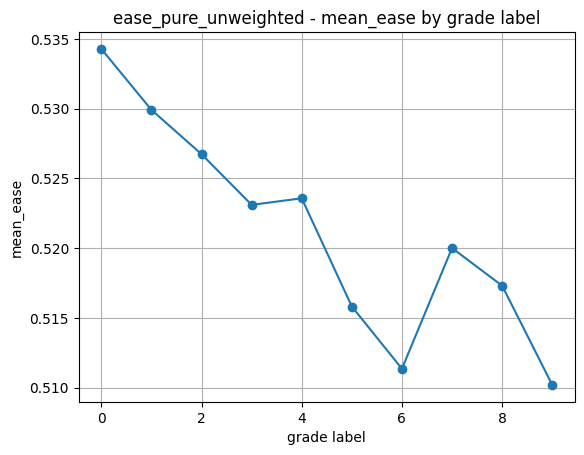

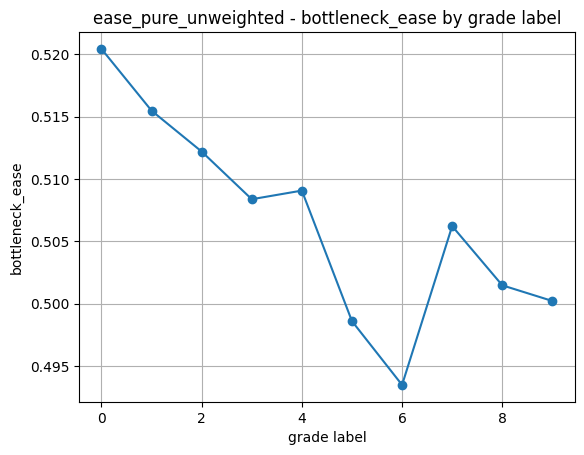

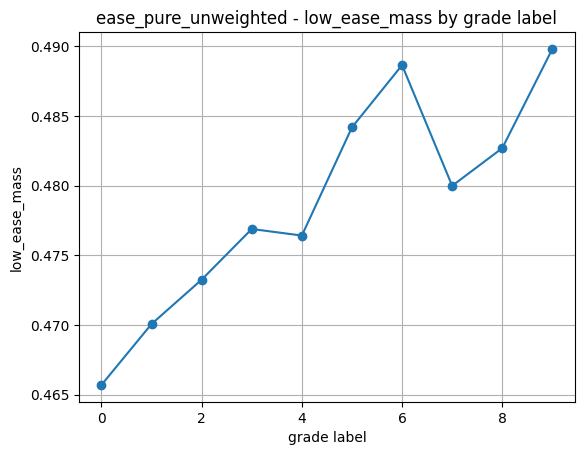

,label,grade_group,mean_ease,bottleneck_ease,low_ease_mass
0,0,6B/6B+,0.820431,0.730723,0.179569
1,1,6C/6C+,0.800280,0.697219,0.199720
2,2,7A,0.783095,0.671068,0.216905
3,3,7A+,0.767361,0.645575,0.232639
4,4,7B/7B+,0.768499,0.652006,0.231501
5,5,7C,0.738717,0.593766,0.261283
6,6,7C+,0.732917,0.589529,0.267083
7,7,8A,0.744046,0.622440,0.255954
8,8,8A+,0.726841,0.579325,0.273159
9,9,8B,0.750981,0.672573,0.249019


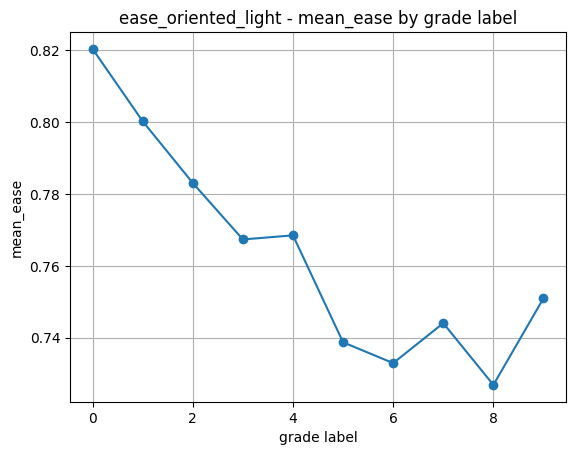

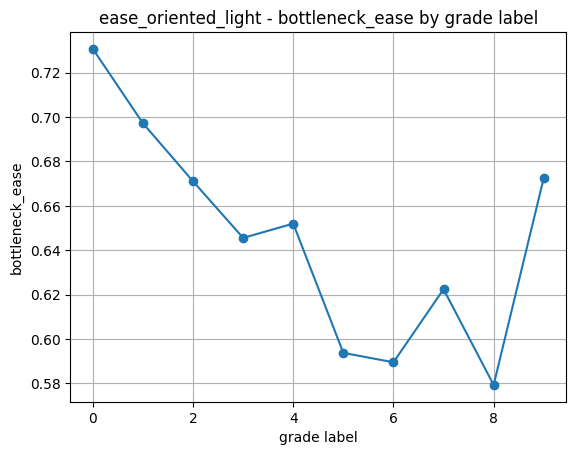

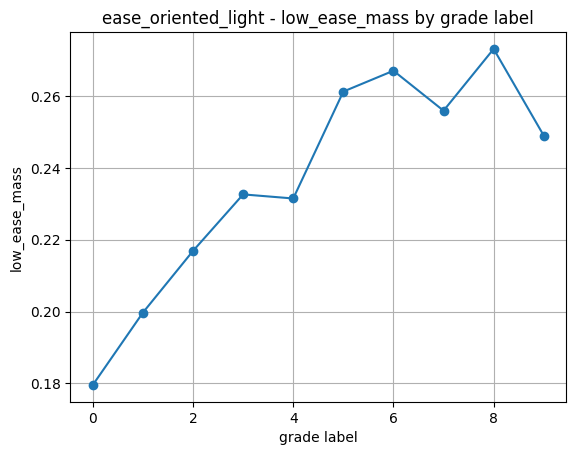

,label,grade_group,mean_ease,bottleneck_ease,low_ease_mass
0,0,6B/6B+,0.828064,0.812691,0.171936
1,1,6C/6C+,0.817213,0.799304,0.182787
2,2,7A,0.806469,0.787637,0.193531
3,3,7A+,0.793275,0.771298,0.206725
4,4,7B/7B+,0.795884,0.775693,0.204116
5,5,7C,0.788355,0.767463,0.211645
6,6,7C+,0.778145,0.755661,0.221855
7,7,8A,0.773516,0.752167,0.226484
8,8,8A+,0.792131,0.772745,0.207869
9,9,8B,0.763589,0.743315,0.236411


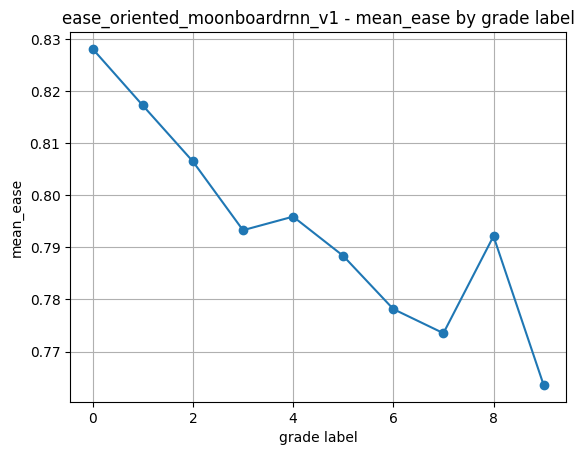

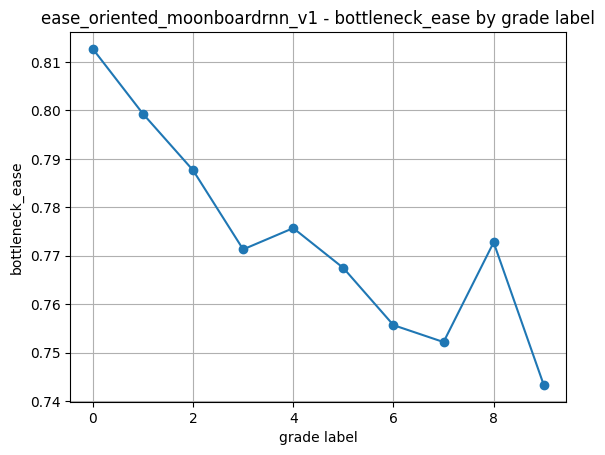

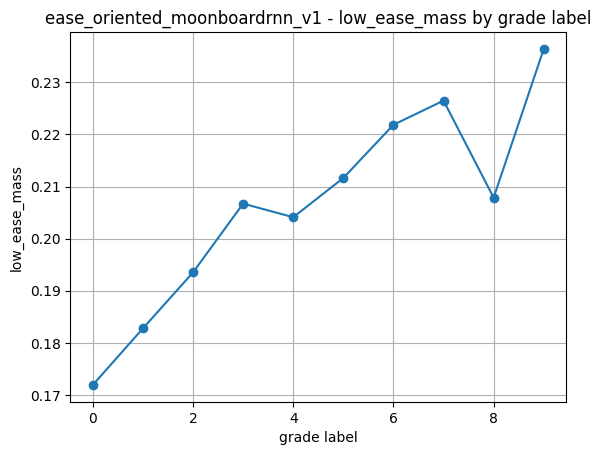

,label,grade_group,mean_ease,bottleneck_ease,low_ease_mass
0,0,6B/6B+,0.971651,0.971384,0.028349
1,1,6C/6C+,0.969662,0.969318,0.030338
2,2,7A,0.967303,0.966912,0.032697
3,3,7A+,0.964448,0.963921,0.035552
4,4,7B/7B+,0.965056,0.964582,0.034944
5,5,7C,0.962452,0.961819,0.037548
6,6,7C+,0.960584,0.959809,0.039416
7,7,8A,0.959881,0.959355,0.040119
8,8,8A+,0.960498,0.960087,0.039502
9,9,8B,0.960546,0.959723,0.039454


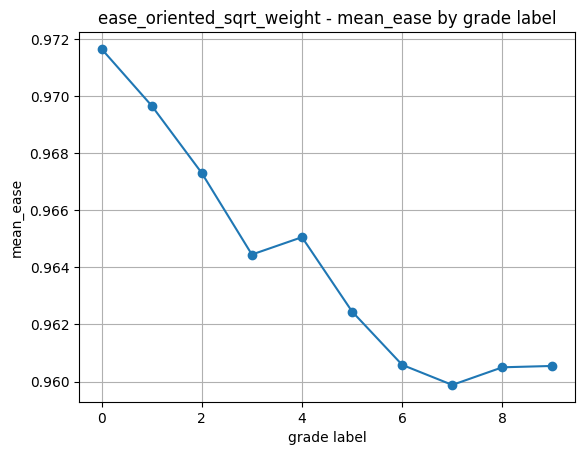

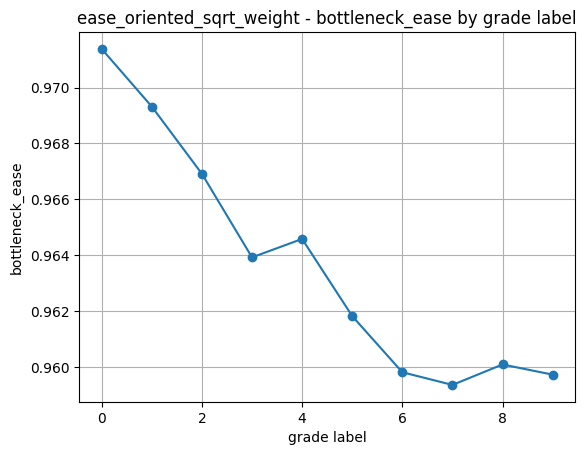

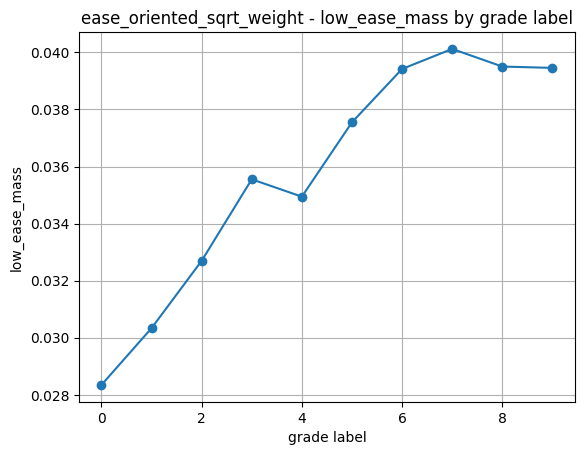

,label,grade_group,mean_ease,bottleneck_ease,low_ease_mass
0,0,6B/6B+,0.907778,0.628990,0.092222
1,1,6C/6C+,0.878559,0.544986,0.121441
2,2,7A,0.858422,0.507611,0.141578
3,3,7A+,0.834003,0.457669,0.165997
4,4,7B/7B+,0.835524,0.459134,0.164476
5,5,7C,0.801873,0.398835,0.198128
6,6,7C+,0.799583,0.433158,0.200417
7,7,8A,0.794543,0.394915,0.205457
8,8,8A+,0.798771,0.357107,0.201229
9,9,8B,0.802999,0.454611,0.197001


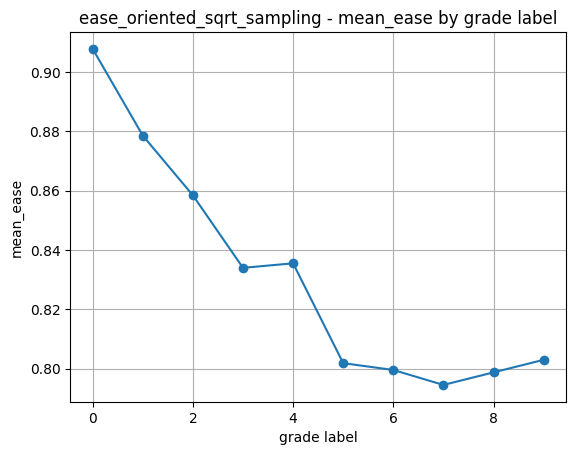

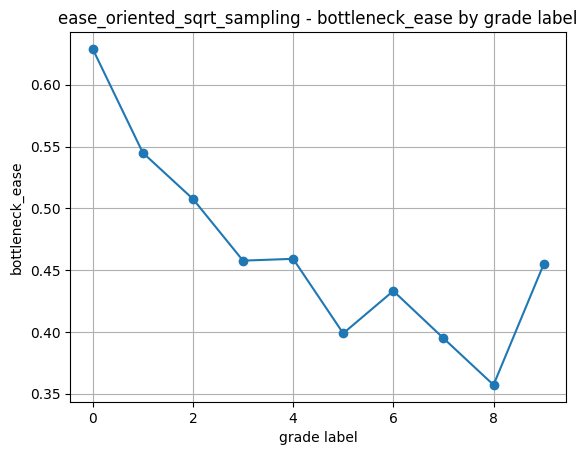

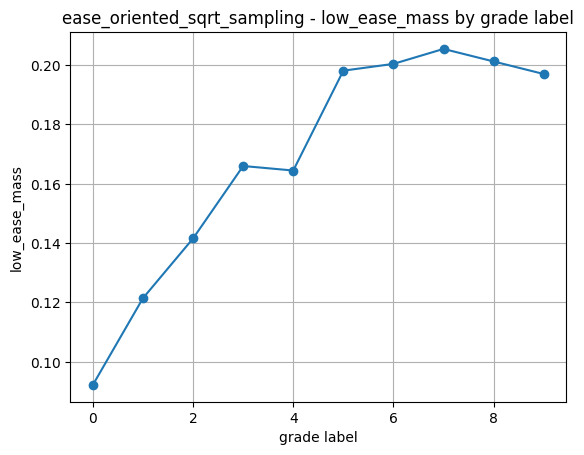

In [15]:
import matplotlib.pyplot as plt

def plot_ease_summary(result: dict, selection: str = "relaxed_acc"):
    metrics = result["test_metrics_by_selection"][selection]
    if "ease_summary" not in metrics:
        print(result["name"], "has no ease summary.")
        return

    ease_summary = metrics["ease_summary"]
    mean_by_label = {int(k): v for k, v in ease_summary["mean_ease_by_label"].items()}
    bottleneck_by_label = {int(k): v for k, v in ease_summary["bottleneck_ease_by_label"].items()}
    low_mass_by_label = {int(k): v for k, v in ease_summary["low_ease_mass_by_label"].items()}

    rows = []
    for label in sorted(mean_by_label):
        rows.append({
            "label": label,
            "grade_group": ID_TO_GRADE_GROUP.get(label, str(label)),
            "mean_ease": mean_by_label[label],
            "bottleneck_ease": bottleneck_by_label[label],
            "low_ease_mass": low_mass_by_label[label],
        })
    df = pd.DataFrame(rows)

    display(df)

    for col in ["mean_ease", "bottleneck_ease", "low_ease_mass"]:
        plt.figure()
        plt.plot(df["label"], df[col], marker="o")
        plt.xlabel("grade label")
        plt.ylabel(col)
        plt.title(f"{result['name']} - {col} by grade label")
        plt.grid(True)
        plt.show()

for r in all_results:
    plot_ease_summary(r, selection="relaxed_acc")

## 11. Recommended next ablations

첫 실행 후에는 아래 실험을 추가해서 sensitivity를 보는 것이 좋습니다.

```python
{
    "name": "ease_gated_oriented_w001_b010",
    "model": "ease_gated",
    "ease_supervision_weight": 0.01,
    "ease_grade_bias_strength": 0.10,
}
{
    "name": "ease_gated_oriented_w005_b025",
    "model": "ease_gated",
    "ease_supervision_weight": 0.05,
    "ease_grade_bias_strength": 0.25,
}
{
    "name": "ease_gated_oriented_w010_b050",
    "model": "ease_gated",
    "ease_supervision_weight": 0.10,
    "ease_grade_bias_strength": 0.50,
}
```

판정 기준은 단순 exact accuracy만 보지 말고 다음을 같이 봐야 합니다.

- `+/-1 accuracy`
- macro-F1
- rare grade class recall
- `corr(label, bottleneck_ease)`가 음수인지
- `corr(label, low_ease_mass)`가 양수인지
- confusion matrix에서 높은 등급을 전부 낮은 등급으로 밀어버리지는 않는지

## 12. How to read the diverse ablation

이 노트북에서 좋은 후보는 단순히 macro-F1만 높은 모델이 아닙니다.

우선순위는 보통 다음 순서로 봅니다.

1. `selected_by_val_relaxed_+/-1`이 baseline에서 크게 떨어지지 않을 것
2. `selected_by_val_relaxed_macro_f1`이 오를 것
3. `selected_by_val_relaxed_rare_recall`이 오를 것
4. `relaxed_corr_label_bottleneck_ease < 0`
5. `relaxed_corr_label_low_ease_mass > 0`
6. confusion matrix에서 높은 class를 무작정 과예측하지 않을 것

데이터 불균형이 심하기 때문에 rare recall만 보면 false positive가 늘 수 있습니다. 따라서 `+/-1`, macro-F1, rare recall, confusion matrix를 같이 봐야 합니다.
